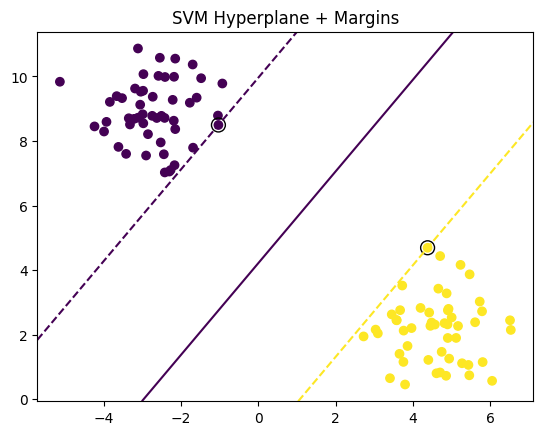

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Step 1: Create dataset (2D)
X, y = make_blobs(n_samples=100, centers=2, random_state=42)

# Step 2: Train model
model = SVC(kernel='linear', C=1)
model.fit(X, y)

# Step 3: Plot
plt.scatter(X[:, 0], X[:, 1], c=y)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# create grid
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# decision boundary
ax.contour(XX, YY, Z, levels=[0])

# margins
ax.contour(XX, YY, Z, levels=[-1, 1], linestyles='dashed')

# support vectors
ax.scatter(model.support_vectors_[:, 0],
           model.support_vectors_[:, 1],
           s=100, facecolors='none', edgecolors='black')

plt.title("SVM Hyperplane + Margins")
plt.show()

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

data = load_breast_cancer()
x=data.data
y=data.target

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

scalar = StandardScaler()

X_train = scalar.fit_transform(X_train)

X_test  =scalar.transform(X_test)

model  = SVC(kernel='linear', C=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))
print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C' : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma' : ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid=param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)
print("Best parameters:" , grid.best_params_)

best_model = grid.best_estimator_
y_pred_grid = best_model.predict(X_test)
print("Accuracy", accuracy_score(y_test,y_pred_grid ))

print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))




              precision    recall  f1-score   support

           0       0.95      0.93      0.94        44
           1       0.96      0.97      0.96        70

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

[[41  3]
 [ 2 68]]
Accuracy: 0.956140350877193
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.